In [3]:
import os
os.chdir('/Users/nchaparla/Documents/Alzheimer-s-Disease-Progression--OASIS')
print(os.getcwd())

/Users/nchaparla/Documents/Alzheimer-s-Disease-Progression--OASIS


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load OASIS-2 longitudinal data
df = pd.read_excel('data/oasis_longitudinal.xlsx')

print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst look:")
df.head()

Shape: (373, 15)

Columns: ['Subject ID', 'MRI ID', 'Group', 'Visit', 'MR Delay', 'M/F', 'Hand', 'Age', 'EDUC', 'SES', 'MMSE', 'CDR', 'eTIV', 'nWBV', 'ASF']

First look:


,Subject ID,MRI ID,Group,Visit,MR Delay,M/F,Hand,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
0,OAS2_0001,OAS2_0001_MR1,Nondemented,1,0,M,R,87,14,2.0,27.0,0.0,1986.550000,0.696106,0.883440
1,OAS2_0001,OAS2_0001_MR2,Nondemented,2,457,M,R,88,14,2.0,30.0,0.0,2004.479526,0.681062,0.875539
2,OAS2_0002,OAS2_0002_MR1,Demented,1,0,M,R,75,12,NaN,23.0,0.5,1678.290000,0.736336,1.045710
3,OAS2_0002,OAS2_0002_MR2,Demented,2,560,M,R,76,12,NaN,28.0,0.5,1737.620000,0.713402,1.010000
4,OAS2_0002,OAS2_0002_MR3,Demented,3,1895,M,R,80,12,NaN,22.0,0.5,1697.911134,0.701236,1.033623


In [5]:
# Data cleaning
print("Missing values:")
print(df.isnull().sum())

print(f"\nGroup distribution:")
print(df['Group'].value_counts())

print(f"\nCDR distribution:")
print(df['CDR'].value_counts().sort_index())

Missing values:
Subject ID     0
MRI ID         0
Group          0
Visit          0
MR Delay       0
M/F            0
Hand           0
Age            0
EDUC           0
SES           19
MMSE           2
CDR            0
eTIV           0
nWBV           0
ASF            0
dtype: int64

Group distribution:
Group
Nondemented    190
Demented       146
Converted       37
Name: count, dtype: int64

CDR distribution:
CDR
0.0    206
0.5    123
1.0     41
2.0      3
Name: count, dtype: int64


In [6]:
# Data preparation
# Drop rows with missing MMSE (only 2)
df = df.dropna(subset=['MMSE'])

# Fill SES missing with median
df['SES'] = df['SES'].fillna(df['SES'].median())

# Encode gender
df['gender'] = df['M/F'].map({'M': 1, 'F': 0})

# Create binary target — Demented vs Non-demented
# Converted = will become demented, so treat as Demented
df['target'] = df['Group'].map({
    'Nondemented': 0,
    'Demented': 1,
    'Converted': 1
})

print(f"Dataset after cleaning: {df.shape}")
print(f"\nTarget distribution:")
print(df['target'].value_counts())
print(f"\nDemented rate: {df['target'].mean()*100:.1f}%")

# Select features
features = ['Age', 'gender', 'EDUC', 'SES', 'MMSE', 'eTIV', 'nWBV', 'ASF', 'CDR']
X = df[features]
y = df['target']

print(f"\nFeatures: {features}")
print(f"X shape: {X.shape}")

Dataset after cleaning: (371, 17)

Target distribution:
target
0    190
1    181
Name: count, dtype: int64

Demented rate: 48.8%

Features: ['Age', 'gender', 'EDUC', 'SES', 'MMSE', 'eTIV', 'nWBV', 'ASF', 'CDR']
X shape: (371, 9)


In [7]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.pipeline import Pipeline

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"\nDemented rate in train: {y_train.mean()*100:.1f}%")
print(f"Demented rate in test: {y_test.mean()*100:.1f}%")

# Define models — KNN and SVM need scaling, so use pipelines
models = {
    'KNN': Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsClassifier(n_neighbors=5))
    ]),
    'Naive Bayes': Pipeline([
        ('scaler', StandardScaler()),
        ('model', GaussianNB())
    ]),
    'SVM (RBF)': Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVC(kernel='rbf', random_state=42, probability=True))
    ]),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, random_state=42, n_jobs=-1
    )
}

# Train and evaluate all models
results = []
for name, model in models.items():
    # Cross-validation on training set
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    
    # Train and test
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    results.append({
        'Model': name,
        'CV Accuracy': round(cv_scores.mean(), 3),
        'Test Accuracy': round((y_pred == y_test).mean(), 3),
        'ROC-AUC': round(roc_auc_score(y_test, y_prob), 3)
    })
    
results_df = pd.DataFrame(results)
print("\nModel Comparison:")
print(results_df.to_string(index=False))

Training set: 296 samples
Test set: 75 samples

Demented rate in train: 48.6%
Demented rate in test: 49.3%

Model Comparison:
        Model  CV Accuracy  Test Accuracy  ROC-AUC
          KNN        0.922          0.933    0.957
  Naive Bayes        0.943          0.947    0.959
    SVM (RBF)        0.946          0.947    0.959
Random Forest        0.943          0.960    0.960


In [8]:
# Detailed results for best model — Random Forest
best_model = models['Random Forest']
y_pred_rf = best_model.predict(X_test)
y_prob_rf = best_model.predict_proba(X_test)[:, 1]

print("Random Forest — Detailed Results:")
print(classification_report(y_test, y_pred_rf, 
      target_names=['Nondemented', 'Demented']))

# Feature importance
feat_imp = pd.Series(
    best_model.feature_importances_, 
    index=features
).sort_values(ascending=False)

print("\nFeature Importance:")
print(feat_imp.round(3))

Random Forest — Detailed Results:
              precision    recall  f1-score   support

 Nondemented       0.93      1.00      0.96        38
    Demented       1.00      0.92      0.96        37

    accuracy                           0.96        75
   macro avg       0.96      0.96      0.96        75
weighted avg       0.96      0.96      0.96        75


Feature Importance:
CDR       0.519
MMSE      0.166
nWBV      0.079
ASF       0.066
eTIV      0.059
Age       0.044
EDUC      0.033
SES       0.021
gender    0.013
dtype: float64


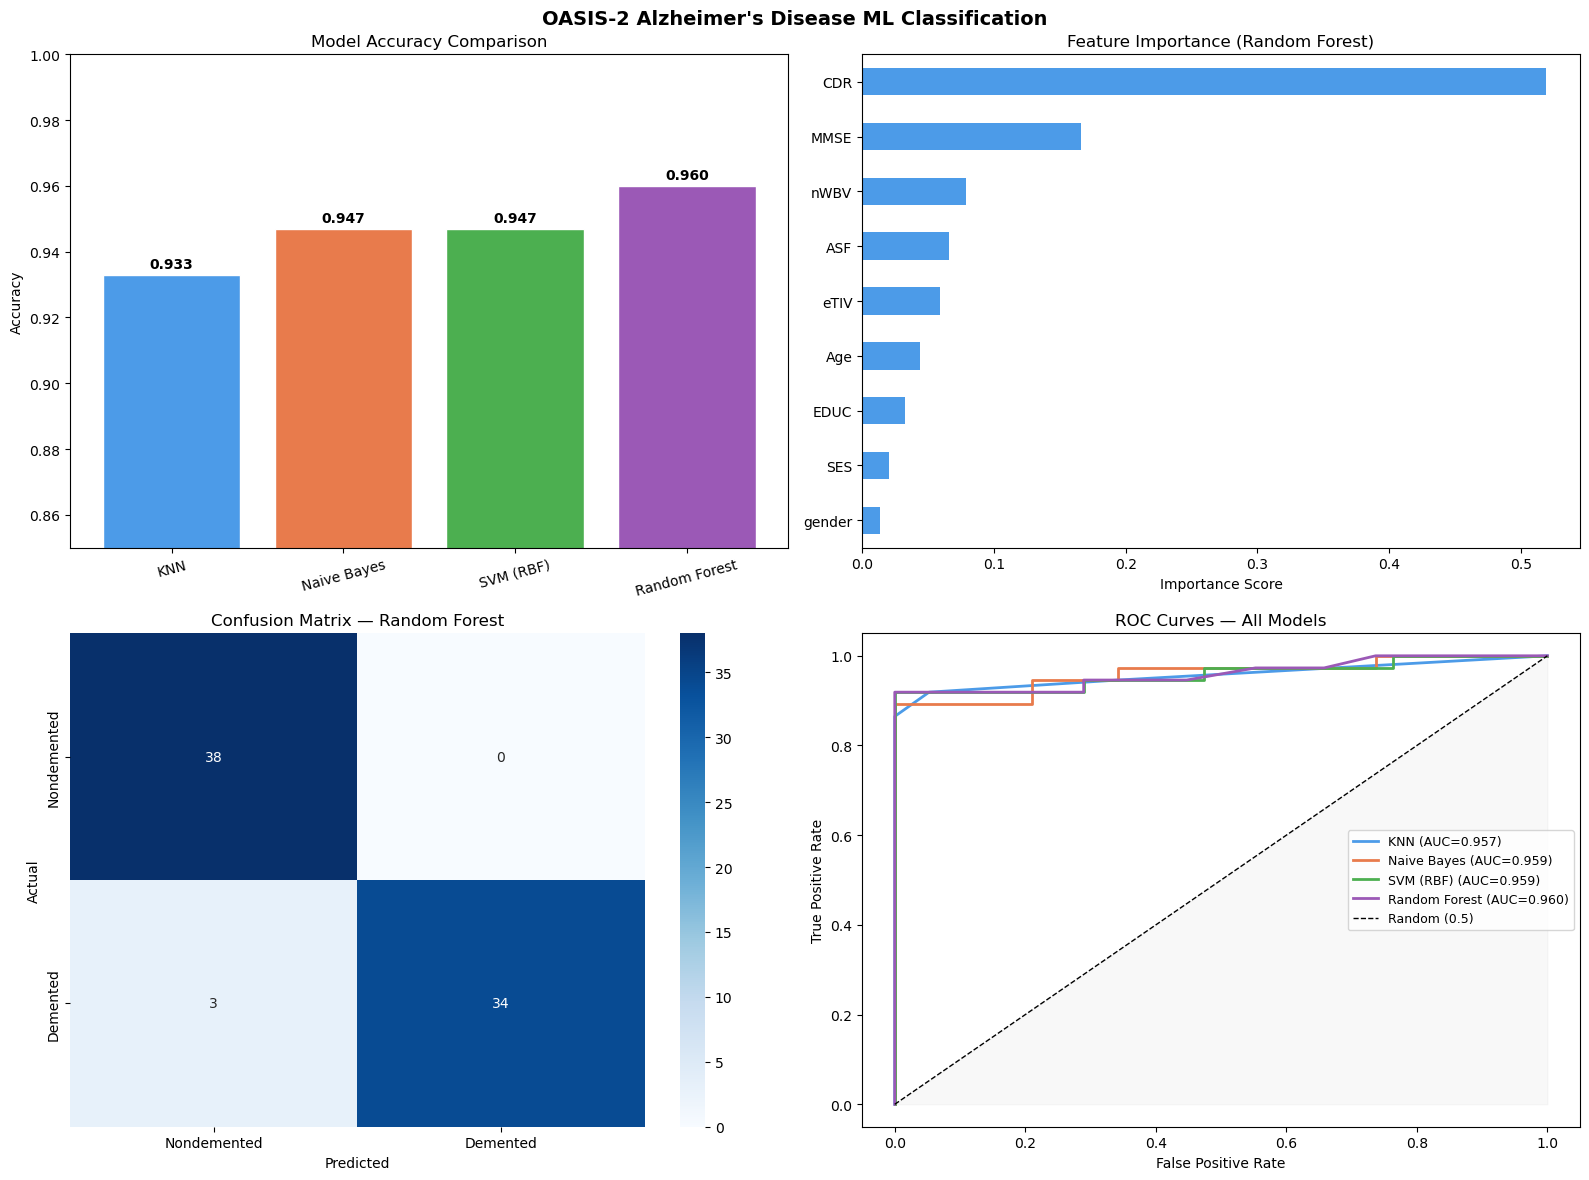

Saved!


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('OASIS-2 Alzheimer\'s Disease ML Classification', 
             fontsize=14, fontweight='bold')

# Chart 1 — Model comparison
colors = ['#4C9BE8', '#E87B4C', '#4CAF50', '#9B59B6']
axes[0,0].bar(results_df['Model'], results_df['Test Accuracy'], 
              color=colors, edgecolor='white')
axes[0,0].set_title('Model Accuracy Comparison')
axes[0,0].set_ylabel('Accuracy')
axes[0,0].set_ylim(0.85, 1.0)
axes[0,0].tick_params(axis='x', rotation=15)
for i, v in enumerate(results_df['Test Accuracy']):
    axes[0,0].text(i, v + 0.002, f'{v:.3f}', ha='center', fontweight='bold')

# Chart 2 — Feature importance
feat_imp.sort_values().plot(kind='barh', ax=axes[0,1], color='#4C9BE8')
axes[0,1].set_title('Feature Importance (Random Forest)')
axes[0,1].set_xlabel('Importance Score')

# Chart 3 — Confusion matrix
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', ax=axes[1,0],
            cmap='Blues',
            xticklabels=['Nondemented', 'Demented'],
            yticklabels=['Nondemented', 'Demented'])
axes[1,0].set_title('Confusion Matrix — Random Forest')
axes[1,0].set_ylabel('Actual')
axes[1,0].set_xlabel('Predicted')

# Chart 4 — ROC curves for all models
from sklearn.metrics import roc_curve
for i, (name, model) in enumerate(models.items()):
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    axes[1,1].plot(fpr, tpr, linewidth=2, color=colors[i],
                   label=f'{name} (AUC={auc:.3f})')

axes[1,1].plot([0,1], [0,1], 'k--', linewidth=1, label='Random (0.5)')
axes[1,1].set_title('ROC Curves — All Models')
axes[1,1].set_xlabel('False Positive Rate')
axes[1,1].set_ylabel('True Positive Rate')
axes[1,1].legend(fontsize=9)
axes[1,1].fill_between([0,1], [0,1], alpha=0.05, color='gray')

plt.tight_layout()
save_path = '/Users/nchaparla/Documents/Alzheimer-s-Disease-Progression--OASIS/outputs/oasis_ml_results.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")